# Análisis de ICD por Zona Vertical de la Plataforma

Este notebook genera gráficas de ICD (Index of Correct Detection) desglosadas por:
- **Zona vertical**: mudline, sub1, sub2, sub3, splash
- **Tipo de elemento**: Brace, Beam, Inclined_leg
- **Severidad de daño**: 5%, 10%, 15%, 25%, 35%, 45% (abolladuras) o hasta 90% (corrosión)

Las gráficas muestran tendencias de ICD con intervalos de confianza del 95%.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

## 1. Configuración de Rutas y Tipo de Daño

In [42]:
# CAMBIAR ESTA VARIABLE PARA ALTERNAR ENTRE TIPOS DE DAÑO
import os
TIPO_DANO = os.environ.get('TIPO_DANO', 'abolladura')  # Opciones: 'abolladura' o 'corrosion'

# Rutas base
BASE_DIR = Path('/home/fcisnerosr/github/Proyecto-doctoral/outputs')
RESULTADOS_ANTIGUOS = BASE_DIR / 'resultados_antiguos' / 'resultados_abolladuras' / 'jupyter_notebooks'
RESULTADOS_NUEVOS = BASE_DIR / 'resultados_nuevos'

# Rutas específicas según tipo de daño
if TIPO_DANO == 'abolladura':
    DATA_DIR = RESULTADOS_NUEVOS / 'abolladuras_2026'
    OUTPUT_DIR = DATA_DIR / 'figures'
    DATA_FILE = DATA_DIR / 'todos_los_resultados_con_ICD_abolladura.xlsx'
    TITULO_BASE = 'Dent'
elif TIPO_DANO == 'corrosion':
    DATA_DIR = RESULTADOS_NUEVOS / 'corrosion_2026'
    OUTPUT_DIR = DATA_DIR / 'figures'
    DATA_FILE = DATA_DIR / 'todos_los_resultados_con_ICD_corrosion.xlsx'
    TITULO_BASE = 'Corrosion'
else:
    raise ValueError(f"TIPO_DANO inválido: {TIPO_DANO}. Use 'abolladura' o 'corrosion'")

# Archivo de mapeo Elemento → Zona
MAPEO_FILE = RESULTADOS_ANTIGUOS / 'Elemento_design_type.csv'

# Crear directorio de salida si no existe
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Tipo de daño: {TIPO_DANO.upper()}")
print(f"Archivo de datos: {DATA_FILE.name}")
print(f"Directorio de salida: {OUTPUT_DIR}")

Tipo de daño: ABOLLADURA
Archivo de datos: todos_los_resultados_con_ICD_abolladura.xlsx
Directorio de salida: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/abolladuras_2026/figures


## 2. Cargar Datos ICD y Mapeo de Zonas

In [43]:
# Cargar datos ICD calculados
print(f"Cargando datos desde: {DATA_FILE}")
df_icd = pd.read_excel(DATA_FILE)
print(f"Datos cargados: {len(df_icd)} filas")
print(f"Columnas: {list(df_icd.columns)}")

# Cargar mapeo Elemento → Zona
print(f"\nCargando mapeo de zonas desde: {MAPEO_FILE}")
df_mapeo = pd.read_csv(MAPEO_FILE)
print(f"Mapeo cargado: {len(df_mapeo)} elementos")
print(f"Zonas encontradas: {sorted(df_mapeo['nivel'].unique())}")

# Crear diccionario de mapeo
mapeo_elemento_zona = dict(zip(df_mapeo['Elemento'], df_mapeo['nivel']))
mapeo_elemento_tipo = dict(zip(df_mapeo['Elemento'], df_mapeo['Design_Type']))

# Agregar columnas de zona y tipo a los datos ICD
df_icd['Zona'] = df_icd['Elemento'].map(mapeo_elemento_zona)
df_icd['Tipo'] = df_icd['Elemento'].map(mapeo_elemento_tipo)

# Verificar que no haya valores nulos
print(f"\nElementos sin zona: {df_icd['Zona'].isna().sum()}")
print(f"Elementos sin tipo: {df_icd['Tipo'].isna().sum()}")

# Mostrar primeras filas
print("\nPrimeras filas con zona y tipo agregados:")
df_icd.head()

Cargando datos desde: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/abolladuras_2026/todos_los_resultados_con_ICD_abolladura.xlsx
Datos cargados: 1080 filas
Columnas: ['ID', 'Elemento', 'Porcentaje', 'Tiempo_s', 'ObjFinal', 'DeteccionOK', 'N_FalsosPositivos', 'alpha1', 'alpha2', 'alpha3', 'alpha4', 'alpha5', 'alpha6', 'alpha7', 'alpha8', 'MAC_minimo', 'MAC_promedio', 'Hubo_cruces_modales', 'C_norm', 'P_FP', 'ICD', 'Tipo_elemento_a_buscar', 'DeteccionOK_binario']

Cargando mapeo de zonas desde: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_antiguos/resultados_abolladuras/jupyter_notebooks/Elemento_design_type.csv
Mapeo cargado: 120 elementos
Zonas encontradas: ['mudline', 'splash', 'sub1', 'sub2', 'sub3']

Elementos sin zona: 0
Elementos sin tipo: 0

Primeras filas con zona y tipo agregados:


,ID,Elemento,Porcentaje,Tiempo_s,ObjFinal,DeteccionOK,N_FalsosPositivos,alpha1,alpha2,alpha3,...,MAC_minimo,MAC_promedio,Hubo_cruces_modales,C_norm,P_FP,ICD,Tipo_elemento_a_buscar,DeteccionOK_binario,Zona,Tipo
0,1,1,5,138.147974,0.925560,0.5,4,0.007319,0.000038,0.000031,...,0.500416,0.752289,False,0.237845,0.548812,0.065266,Inclined_leg,1,mudline,Inclined_leg
1,2,1,10,222.056862,0.909825,0.5,4,0.003770,0.000043,0.000027,...,0.500436,0.752465,False,0.406598,0.548812,0.111573,Inclined_leg,1,mudline,Inclined_leg
2,3,1,15,305.609196,0.887863,0.5,4,0.000007,0.000003,0.000012,...,0.500640,0.753898,False,0.537493,0.548812,0.147491,Inclined_leg,1,mudline,Inclined_leg
3,4,1,20,388.987465,0.846761,0.5,4,0.000027,0.000002,0.000025,...,0.502512,0.804982,False,0.644443,0.548812,0.176839,Inclined_leg,1,mudline,Inclined_leg
4,5,1,25,453.769687,0.796903,0.5,2,0.000108,0.000016,0.000008,...,0.500959,0.754893,False,0.734867,0.740818,0.272201,Inclined_leg,1,mudline,Inclined_leg


## 3. Preparar Datos para Visualización

In [44]:
# Orden de zonas (de abajo hacia arriba en la plataforma)
ordered_zones = ['mudline', 'sub1', 'sub2', 'sub3', 'splash']

# Filtrar solo zonas que existen en los datos
existing_zones = [z for z in ordered_zones if z in df_icd['Zona'].values]
print(f"Zonas a graficar: {existing_zones}")

# Tipos de elementos
tipos_elementos = sorted(df_icd['Tipo'].unique())
print(f"Tipos de elementos: {tipos_elementos}")

# Severidades de daño
porcentajes = sorted(df_icd['Porcentaje'].unique())
print(f"Severidades de daño (%): {porcentajes}")

Zonas a graficar: ['mudline', 'sub1', 'sub2', 'sub3', 'splash']
Tipos de elementos: ['Beam', 'Brace', 'Inclined_leg']
Severidades de daño (%): [5, 10, 15, 20, 25, 30, 35, 40, 45]


## 4. Calcular Estadísticas por Zona, Tipo y Porcentaje

In [45]:
# Agrupar y calcular estadísticas
summary = df_icd.groupby(['Zona', 'Tipo', 'Porcentaje']).agg(
    icd_mean=('ICD', 'mean'),
    icd_std=('ICD', 'std'),
    n=('ICD', 'size')
).reset_index()

# Calcular intervalo de confianza del 95% (Wilson score o normal)
# IC = 1.96 * std / sqrt(n)
summary['icd_ci_half'] = 1.96 * (summary['icd_std'] / np.sqrt(summary['n']))
summary['icd_ci_lo'] = summary['icd_mean'] - summary['icd_ci_half']
summary['icd_ci_hi'] = summary['icd_mean'] + summary['icd_ci_half']

# Asegurar que IC no sea negativo ni mayor a 1
summary['icd_ci_lo'] = summary['icd_ci_lo'].clip(lower=0)
summary['icd_ci_hi'] = summary['icd_ci_hi'].clip(upper=1)

print(f"Total de combinaciones Zona×Tipo×Porcentaje: {len(summary)}")
summary.head(15)

Total de combinaciones Zona×Tipo×Porcentaje: 135


,Zona,Tipo,Porcentaje,icd_mean,icd_std,n,icd_ci_half,icd_ci_lo,icd_ci_hi
0,mudline,Beam,5,0.118922,0.000000,4,0.000000,0.118922,0.118922
1,mudline,Beam,10,0.203299,0.000000,4,0.000000,0.203299,0.203299
2,mudline,Beam,15,0.268747,0.000000,4,0.000000,0.268747,0.268747
3,mudline,Beam,20,0.322221,0.000000,4,0.000000,0.322221,0.322221
4,mudline,Beam,25,0.367433,0.000000,4,0.000000,0.367433,0.367433
5,mudline,Beam,30,0.406598,0.000000,4,0.000000,0.406598,0.406598
6,mudline,Beam,35,0.441144,0.000000,4,0.000000,0.441144,0.441144
7,mudline,Beam,40,0.472046,0.000000,4,0.000000,0.472046,0.472046
8,mudline,Beam,45,0.500000,0.000000,4,0.000000,0.500000,0.500000
9,mudline,Brace,5,0.200522,0.025561,16,0.012525,0.187997,0.213047


## 5. Generar Gráficas de ICD por Zona


Figura guardada en: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/abolladuras_2026/figures/ICD_by_zone_abolladura.png


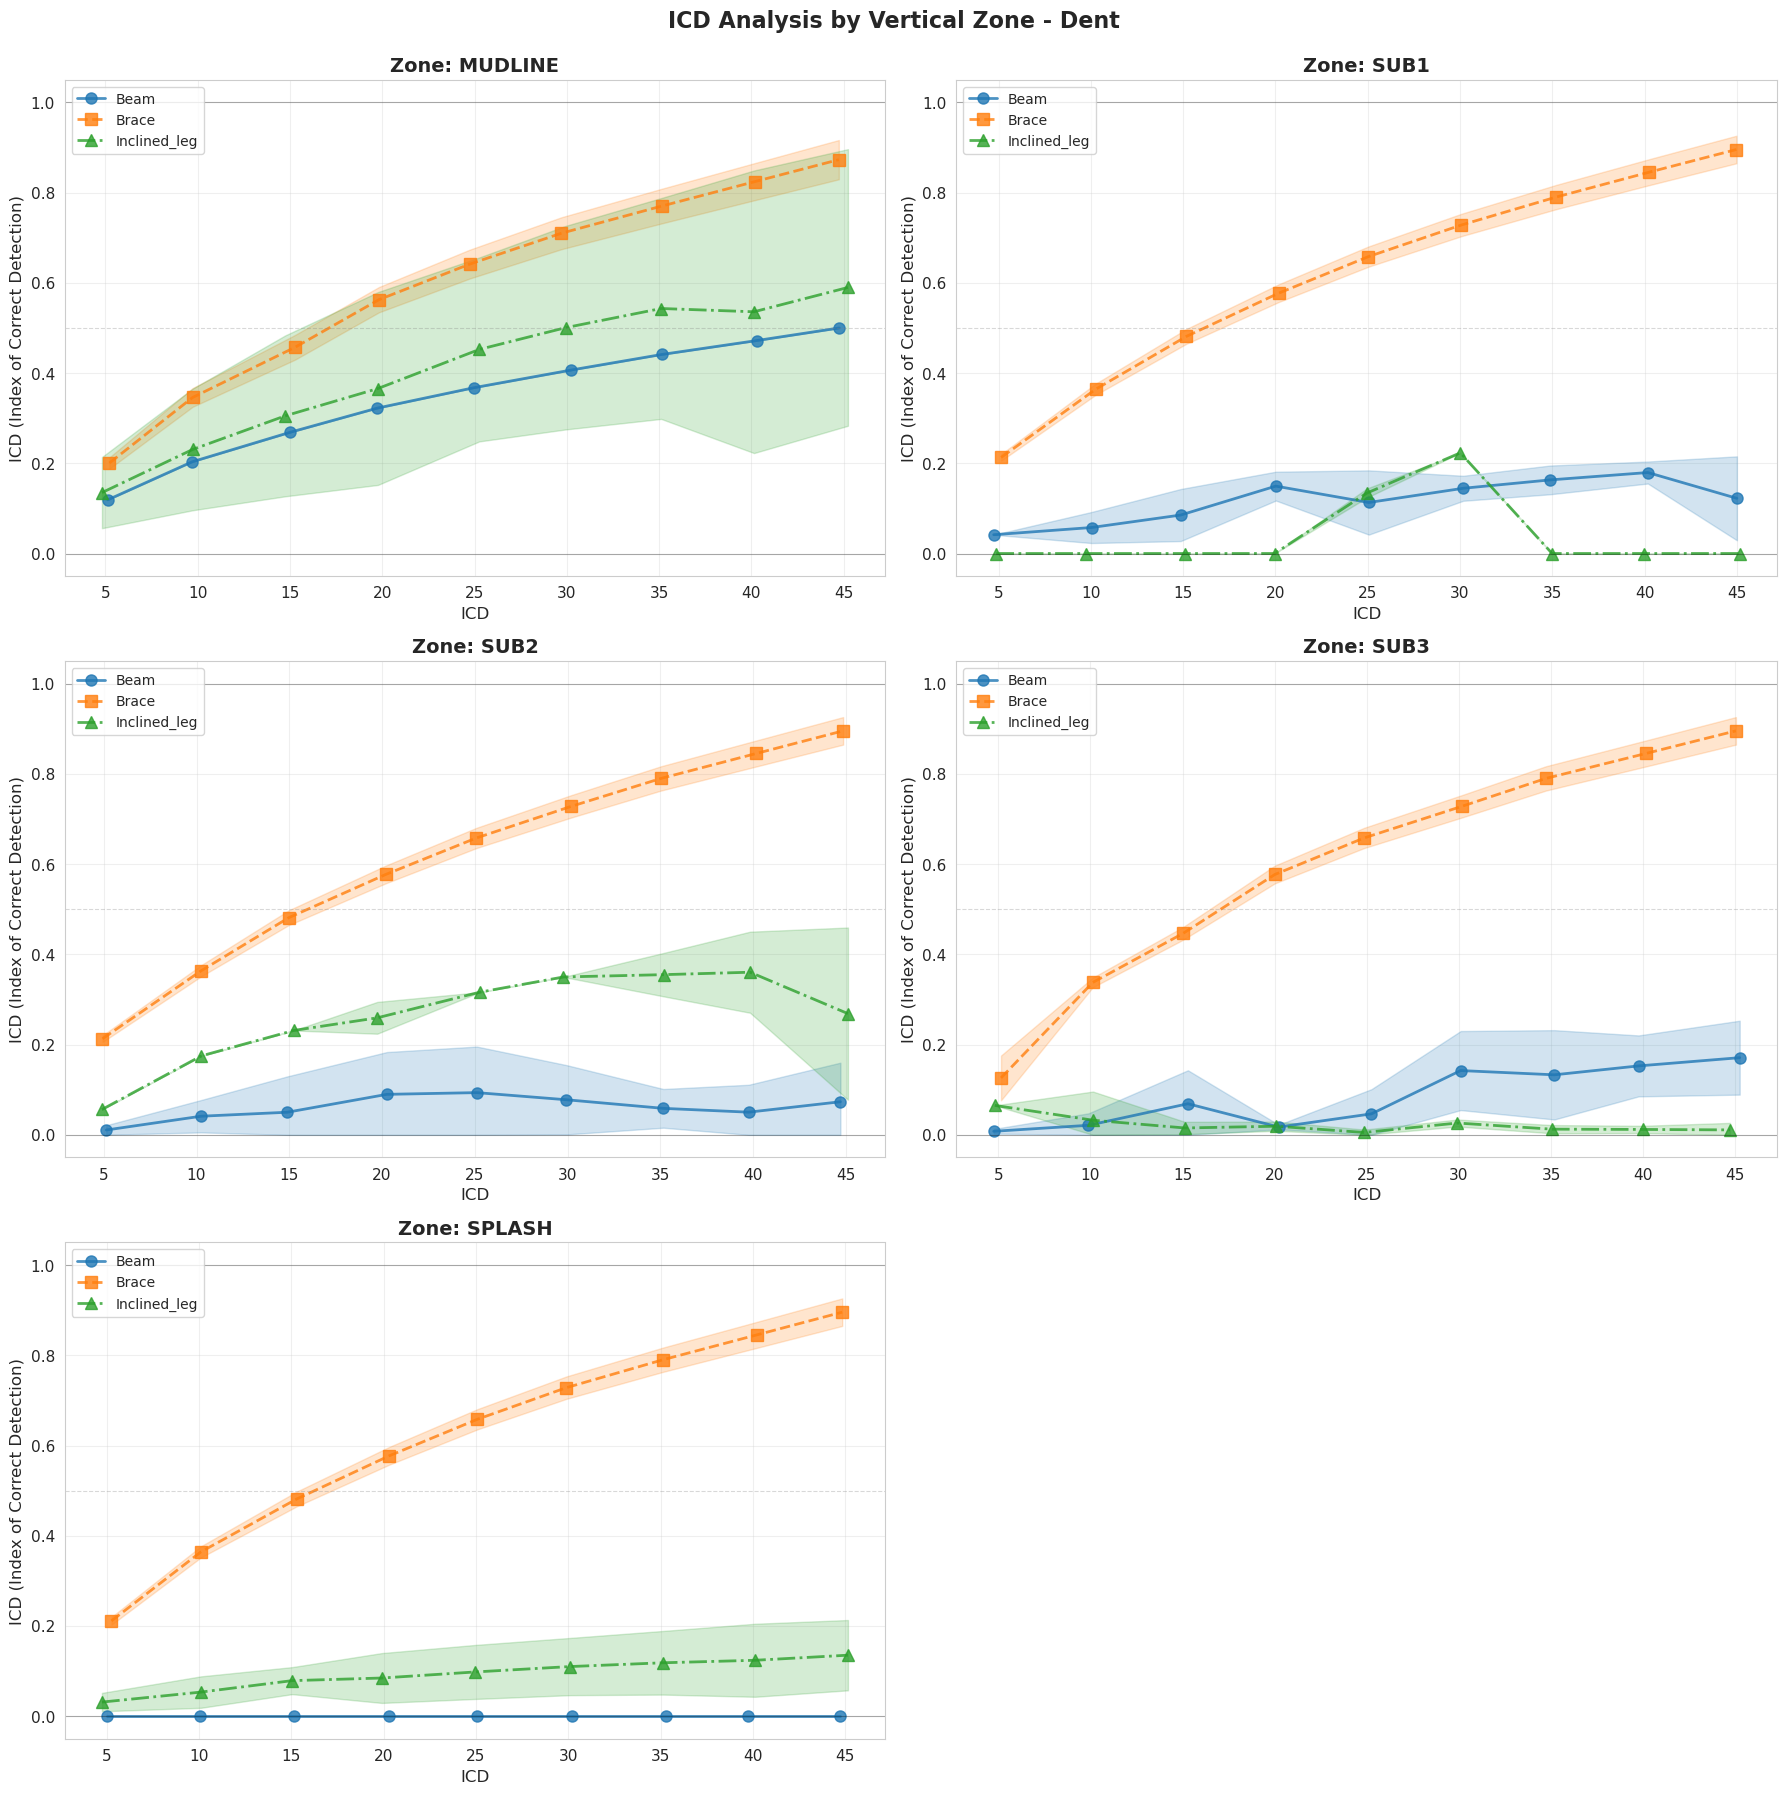

In [46]:
# Configuración de gráficas
n_zonas = len(existing_zones)
n_cols = 2
n_rows = int(np.ceil(n_zonas / n_cols))

# Crear figura con subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_zonas > 1 else [axes]

# Paleta de colores y estilos de línea
colores = plt.cm.tab10.colors
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']

# Mapeo de tipos a colores/estilos
tipo_config = {
    tipo: {
        'color': colores[i % len(colores)],
        'linestyle': line_styles[i % len(line_styles)],
        'marker': markers[i % len(markers)]
    }
    for i, tipo in enumerate(tipos_elementos)
}

# Graficar cada zona
for idx, zona in enumerate(existing_zones):
    ax = axes[idx]
    
    # Filtrar datos de esta zona
    df_zona = summary[summary['Zona'] == zona]
    
    # Graficar cada tipo de elemento
    for tipo in tipos_elementos:
        df_tipo = df_zona[df_zona['Tipo'] == tipo].sort_values('Porcentaje')
        
        if len(df_tipo) == 0:
            continue
        
        # Agregar jitter horizontal para separar visualmente las líneas
        jitter = np.random.uniform(-0.3, 0.3, size=len(df_tipo))
        x_jittered = df_tipo['Porcentaje'].values + jitter
        
        config = tipo_config[tipo]
        
        # Línea principal con intervalo de confianza
        ax.plot(x_jittered, df_tipo['icd_mean'], 
                color=config['color'], 
                linestyle=config['linestyle'],
                marker=config['marker'],
                linewidth=2, 
                markersize=8,
                label=tipo, 
                alpha=0.8)
        
        # Banda de intervalo de confianza
        ax.fill_between(x_jittered,
                       df_tipo['icd_ci_lo'],
                       df_tipo['icd_ci_hi'],
                       color=config['color'],
                       alpha=0.2)
    
    # Configuración del subplot
    ax.set_title(f"Zone: {zona.upper()}", fontsize=14, fontweight='bold')
    ax.set_xlabel('DQI', fontsize=12)
    ax.set_ylabel('Detection Quality Index (DQI)', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10)
    
    # Líneas de referencia
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
    ax.axhline(y=1, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.3)

# Ocultar ejes sobrantes si n_zonas es impar
for idx in range(n_zonas, len(axes)):
    axes[idx].set_visible(False)

# Título general
fig.suptitle(f'DQI Analysis by Vertical Zone - {TITULO_BASE}', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()

# Guardar figura
output_file = OUTPUT_DIR / f'ICD_by_zone_{TIPO_DANO}.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\nFigura guardada en: {output_file}")

plt.show()

## 6. Estadísticas Resumen por Zona

In [47]:
# Calcular ICD promedio por zona
icd_por_zona = df_icd.groupby('Zona')['ICD'].agg(['mean', 'std', 'count']).round(4)
icd_por_zona = icd_por_zona.loc[existing_zones]  # Ordenar
print("\n=== ICD Promedio por Zona ===")
print(icd_por_zona)

# Calcular ICD promedio por zona y tipo
icd_zona_tipo = df_icd.groupby(['Zona', 'Tipo'])['ICD'].agg(['mean', 'std', 'count']).round(4)
print("\n=== ICD Promedio por Zona y Tipo ===")
print(icd_zona_tipo)

# Identificar zona con mejor/peor ICD
mejor_zona = icd_por_zona['mean'].idxmax()
peor_zona = icd_por_zona['mean'].idxmin()
print(f"\n✓ Mejor zona (ICD más alto): {mejor_zona.upper()} (ICD = {icd_por_zona.loc[mejor_zona, 'mean']:.4f})")
print(f"✗ Peor zona (ICD más bajo): {peor_zona.upper()} (ICD = {icd_por_zona.loc[peor_zona, 'mean']:.4f})")


=== ICD Promedio por Zona ===
           mean     std  count
Zona                          
mudline  0.5241  0.2398    216
sub1     0.4375  0.3155    216
sub2     0.4654  0.2919    216
sub3     0.4181  0.3305    216
splash   0.4266  0.3267    216

=== ICD Promedio por Zona y Tipo ===
                        mean     std  count
Zona    Tipo                               
mudline Beam          0.3445  0.1225     36
        Brace         0.5984  0.2245    144
        Inclined_leg  0.4065  0.2496     36
splash  Beam          0.0000  0.0000     36
        Brace         0.6168  0.2219    144
        Inclined_leg  0.0926  0.0618     36
sub1    Beam          0.1174  0.0632     36
        Brace         0.6170  0.2215    144
        Inclined_leg  0.0397  0.0783     36
sub2    Beam          0.0606  0.0687     36
        Brace         0.6170  0.2215    144
        Inclined_leg  0.2636  0.1159     36
sub3    Beam          0.0846  0.0853     36
        Brace         0.6006  0.2475    144
        In

## 7. Comparación entre Tipos de Elementos


=== ICD Promedio por Tipo de Elemento ===
                mean     std  count
Tipo                               
Beam          0.1214  0.1416    180
Brace         0.6099  0.2271    720
Inclined_leg  0.1649  0.1972    180

Figura de barras guardada en: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/abolladuras_2026/figures/ICD_by_element_type_abolladura.png


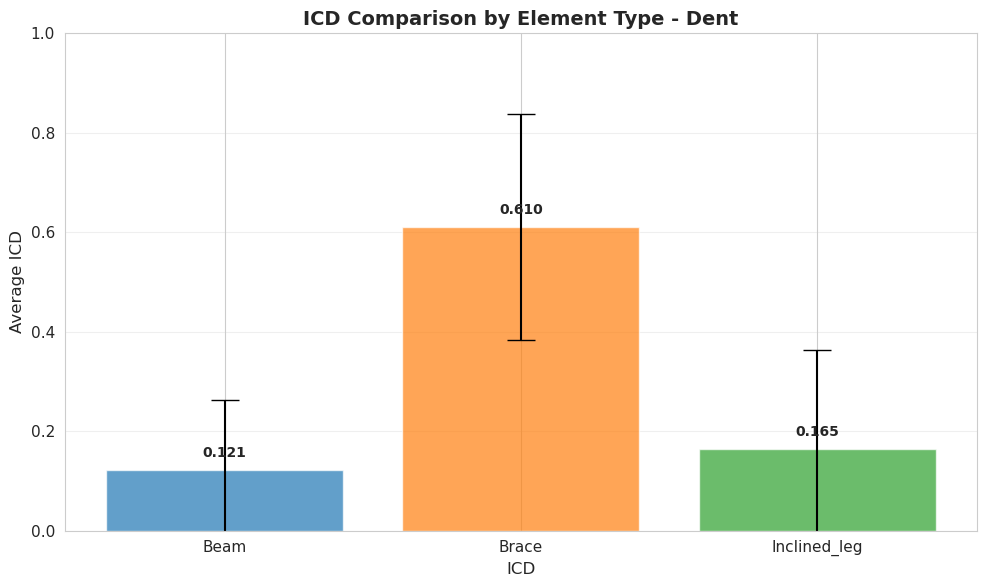

In [48]:
# Comparar tipos de elementos
icd_por_tipo = df_icd.groupby('Tipo')['ICD'].agg(['mean', 'std', 'count']).round(4)
print("\n=== ICD Promedio por Tipo de Elemento ===")
print(icd_por_tipo)

# Gráfica comparativa de barras
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(tipos_elementos))
means = [icd_por_tipo.loc[tipo, 'mean'] for tipo in tipos_elementos]
stds = [icd_por_tipo.loc[tipo, 'std'] for tipo in tipos_elementos]

bars = ax.bar(x_pos, means, yerr=stds, alpha=0.7, capsize=10,
              color=[tipo_config[tipo]['color'] for tipo in tipos_elementos])

ax.set_xlabel('DQI', fontsize=12)
ax.set_ylabel('Average DQI', fontsize=12)
ax.set_title(f'DQI Comparison by Element Type - {TITULO_BASE}', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(tipos_elementos, rotation=0)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, (bar, mean) in enumerate(zip(bars, means)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
           f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
output_file_bars = OUTPUT_DIR / f'ICD_by_element_type_{TIPO_DANO}.png'
plt.savefig(output_file_bars, dpi=300, bbox_inches='tight')
print(f"\nFigura de barras guardada en: {output_file_bars}")
plt.show()

## 8. Análisis de Progresión de Severidad


=== ICD Promedio por Severidad de Daño ===
              mean     std  count
Porcentaje                       
5           0.1441  0.0888    120
10          0.2640  0.1428    120
15          0.3498  0.1877    120
20          0.4264  0.2295    120
25          0.4907  0.2553    120
30          0.5491  0.2730    120
35          0.5849  0.3125    120
40          0.6237  0.3366    120
45          0.6564  0.3623    120

Figura de progresión guardada en: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/abolladuras_2026/figures/ICD_progression_abolladura.png


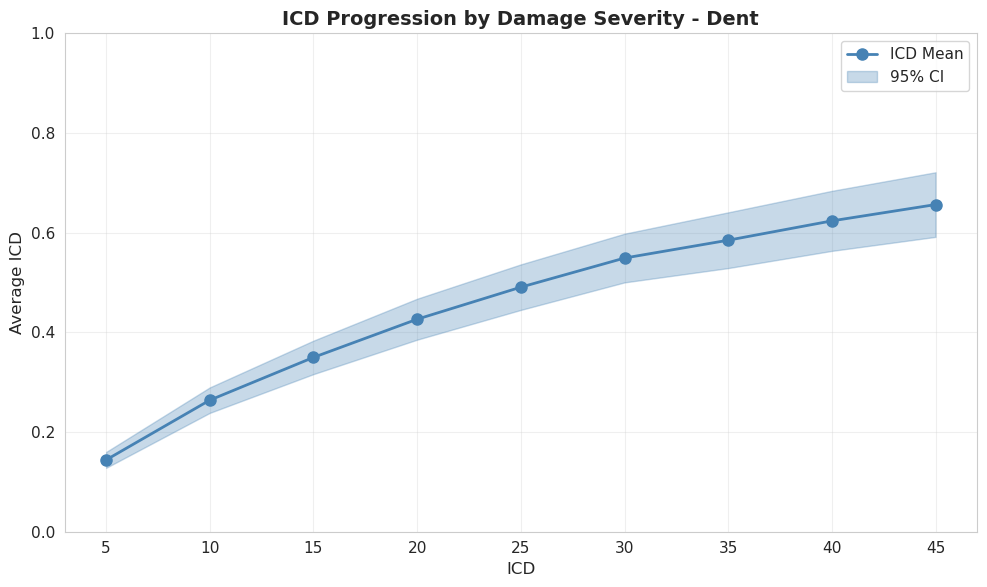

In [49]:
# Analizar cómo ICD cambia con la severidad de daño
icd_por_severidad = df_icd.groupby('Porcentaje')['ICD'].agg(['mean', 'std', 'count']).round(4)
print("\n=== ICD Promedio por Severidad de Daño ===")
print(icd_por_severidad)

# Gráfica de tendencia general
fig, ax = plt.subplots(figsize=(10, 6))

x = icd_por_severidad.index
y = icd_por_severidad['mean']
y_err = 1.96 * (icd_por_severidad['std'] / np.sqrt(icd_por_severidad['count']))

ax.plot(x, y, marker='o', linewidth=2, markersize=8, color='steelblue', label='ICD Mean')
ax.fill_between(x, y - y_err, y + y_err, alpha=0.3, color='steelblue', label='95% CI')

ax.set_xlabel('DQI', fontsize=12)
ax.set_ylabel('Average DQI', fontsize=12)
ax.set_title(f'DQI Progression by Damage Severity - {TITULO_BASE}', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
output_file_prog = OUTPUT_DIR / f'ICD_progression_{TIPO_DANO}.png'
plt.savefig(output_file_prog, dpi=300, bbox_inches='tight')
print(f"\nFigura de progresión guardada en: {output_file_prog}")
plt.show()

## 9. Resumen Final

In [50]:
print("\n" + "="*60)
print(f"RESUMEN DEL ANÁLISIS - {TITULO_BASE.upper()}")
print("="*60)

print(f"\n📊 Total de casos analizados: {len(df_icd)}")
print(f"📍 Zonas analizadas: {', '.join([z.upper() for z in existing_zones])}")
print(f"🔧 Tipos de elementos: {', '.join(tipos_elementos)}")
print(f"📈 Severidades de daño: {', '.join(map(str, porcentajes))}%")

print(f"\n📉 ICD PROMEDIO GLOBAL: {df_icd['ICD'].mean():.4f} ± {df_icd['ICD'].std():.4f}")

print(f"\n🏆 MEJOR ZONA: {mejor_zona.upper()} (ICD = {icd_por_zona.loc[mejor_zona, 'mean']:.4f})")
print(f"❌ PEOR ZONA: {peor_zona.upper()} (ICD = {icd_por_zona.loc[peor_zona, 'mean']:.4f})")

mejor_tipo = icd_por_tipo['mean'].idxmax()
peor_tipo = icd_por_tipo['mean'].idxmin()
print(f"\n🏆 MEJOR TIPO: {mejor_tipo} (ICD = {icd_por_tipo.loc[mejor_tipo, 'mean']:.4f})")
print(f"❌ PEOR TIPO: {peor_tipo} (ICD = {icd_por_tipo.loc[peor_tipo, 'mean']:.4f})")

mejor_severidad = icd_por_severidad['mean'].idxmax()
peor_severidad = icd_por_severidad['mean'].idxmin()
print(f"\n🏆 MEJOR SEVERIDAD: {mejor_severidad}% (ICD = {icd_por_severidad.loc[mejor_severidad, 'mean']:.4f})")
print(f"❌ PEOR SEVERIDAD: {peor_severidad}% (ICD = {icd_por_severidad.loc[peor_severidad, 'mean']:.4f})")

print(f"\n💾 Figuras guardadas en: {OUTPUT_DIR}")
print("="*60)


RESUMEN DEL ANÁLISIS - DENT

📊 Total de casos analizados: 1080
📍 Zonas analizadas: MUDLINE, SUB1, SUB2, SUB3, SPLASH
🔧 Tipos de elementos: Beam, Brace, Inclined_leg
📈 Severidades de daño: 5, 10, 15, 20, 25, 30, 35, 40, 45%

📉 ICD PROMEDIO GLOBAL: 0.4543 ± 0.3046

🏆 MEJOR ZONA: MUDLINE (ICD = 0.5241)
❌ PEOR ZONA: SUB3 (ICD = 0.4181)

🏆 MEJOR TIPO: Brace (ICD = 0.6099)
❌ PEOR TIPO: Beam (ICD = 0.1214)

🏆 MEJOR SEVERIDAD: 45% (ICD = 0.6564)
❌ PEOR SEVERIDAD: 5% (ICD = 0.1441)

💾 Figuras guardadas en: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/abolladuras_2026/figures
